In [1]:
!pip install -q "gymnasium[classic-control]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.3 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)


In [4]:
state, info = env.reset()

print("Initial State:")
print(state)

Initial State:
[-0.04805132  0.0369244   0.04521959 -0.00945089]


In [5]:
# Number of bins for each state variable
bins = (6, 6, 12, 12)

# Ranges for discretization
state_bounds = [
    [-4.8, 4.8],          # Cart position
    [-5.0, 5.0],          # Cart velocity
    [-0.418, 0.418],      # Pole angle
    [-5.0, 5.0]           # Pole angular velocity
]

def discretize_state(state):
    state = np.clip(
        state,
        [b[0] for b in state_bounds],
        [b[1] for b in state_bounds]
    )

    discrete_state = []

    for i in range(len(state)):
        value = (state[i] - state_bounds[i][0]) / (
            state_bounds[i][1] - state_bounds[i][0]
        )

        index = int(value * bins[i])
        index = min(index, bins[i] - 1)

        discrete_state.append(index)

    return tuple(discrete_state)

In [6]:
q_table = np.zeros(bins + (env.action_space.n,))

print("Q-table shape:", q_table.shape)

Q-table shape: (6, 6, 12, 12, 2)


In [7]:
learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500

In [8]:
rewards = []

for episode in range(episodes):

    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0
    done = False

    while not done:

        # Exploration vs Exploitation
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_state = discretize_state(next_state)

        # Q-learning update
        best_next_action = np.max(q_table[next_state])

        q_table[state][action] += learning_rate * (
            reward +
            discount_factor * best_next_action -
            q_table[state][action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

    # Reduce exploration
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % 50 == 0:
        print(
            f"Episode: {episode + 1}, "
            f"Reward: {total_reward:.0f}, "
            f"Epsilon: {epsilon:.3f}"
        )

Episode: 50, Reward: 22, Epsilon: 0.778
Episode: 100, Reward: 15, Epsilon: 0.606
Episode: 150, Reward: 35, Epsilon: 0.471
Episode: 200, Reward: 24, Epsilon: 0.367
Episode: 250, Reward: 16, Epsilon: 0.286
Episode: 300, Reward: 12, Epsilon: 0.222
Episode: 350, Reward: 15, Epsilon: 0.173
Episode: 400, Reward: 12, Epsilon: 0.135
Episode: 450, Reward: 49, Epsilon: 0.105
Episode: 500, Reward: 16, Epsilon: 0.082


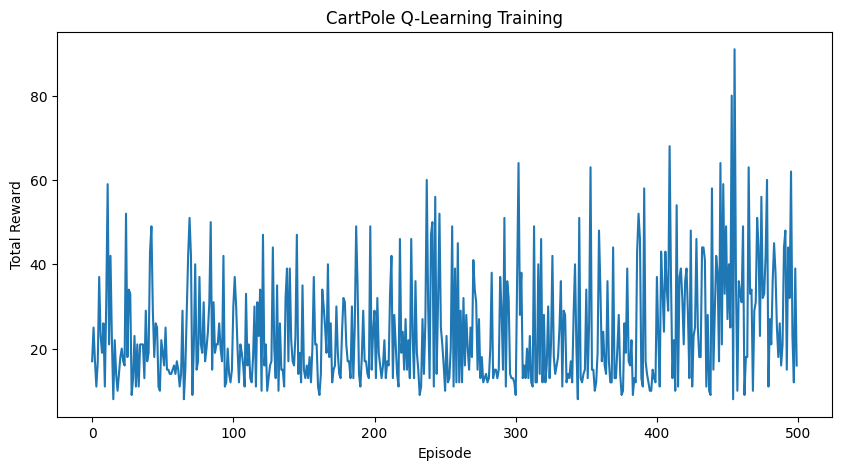

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(rewards)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CartPole Q-Learning Training")

plt.show()

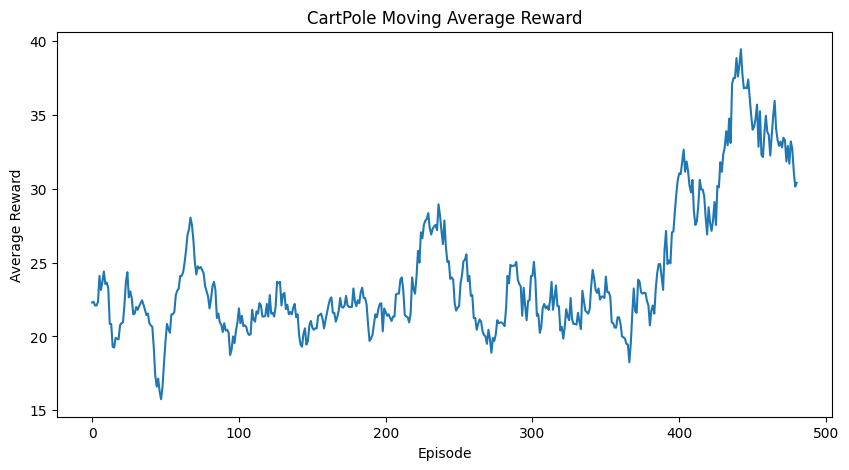

In [10]:
moving_average = np.convolve(
    rewards,
    np.ones(20) / 20,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("CartPole Moving Average Reward")

plt.show()

In [11]:
test_env = gym.make("CartPole-v1")

test_rewards = []

for episode in range(10):

    state, info = test_env.reset()
    state = discretize_state(state)

    total_reward = 0
    done = False

    while not done:

        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = test_env.step(action)

        done = terminated or truncated

        state = discretize_state(next_state)

        total_reward += reward

    test_rewards.append(total_reward)

    print(
        f"Test Episode {episode + 1}: "
        f"Reward = {total_reward:.0f}"
    )

test_env.close()

print("\nAverage Test Reward:", np.mean(test_rewards))

Test Episode 1: Reward = 43
Test Episode 2: Reward = 26
Test Episode 3: Reward = 33
Test Episode 4: Reward = 24
Test Episode 5: Reward = 54
Test Episode 6: Reward = 16
Test Episode 7: Reward = 50
Test Episode 8: Reward = 20
Test Episode 9: Reward = 34
Test Episode 10: Reward = 50

Average Test Reward: 35.0


In [12]:
from IPython.display import display
from PIL import Image
import time

render_env = gym.make("CartPole-v1", render_mode="rgb_array")

state, info = render_env.reset()
state = discretize_state(state)

frames = []

done = False

while not done:

    frame = render_env.render()
    frames.append(frame)

    action = np.argmax(q_table[state])

    next_state, reward, terminated, truncated, info = render_env.step(action)

    done = terminated or truncated

    state = discretize_state(next_state)

render_env.close()

print("Episode completed!")
print("Number of frames:", len(frames))

Episode completed!
Number of frames: 11


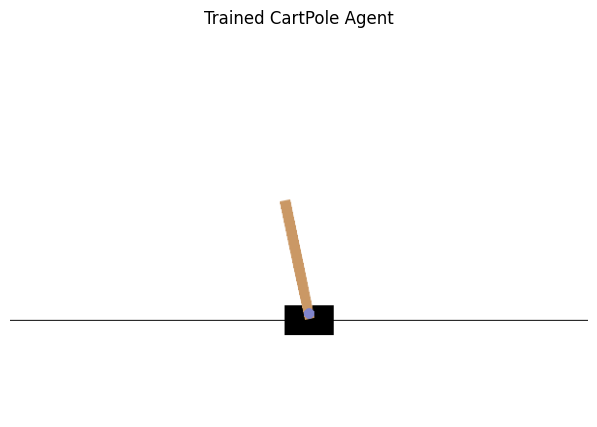

In [13]:
plt.figure(figsize=(8, 5))

plt.imshow(frames[-1])
plt.axis("off")
plt.title("Trained CartPole Agent")

plt.show()

In [14]:
np.save("cartpole_q_table.npy", q_table)

print("Q-table saved successfully!")

Q-table saved successfully!
